In [6]:
# https://github.com/karpathy/micrograd

import math
import numpy as np
import matplotlib.pyplot as plt

In [46]:
def f(x):
    return 3*x**3 + 10*x + 5

In [32]:
y = np.arange(-4, 4, 0.3)

In [33]:
f(y)

array([13.  ,  9.07,  5.68,  2.83,  0.52, -1.25, -2.48, -3.17, -3.32,
       -2.93, -2.  , -0.53,  1.48,  4.03,  7.12, 10.75, 14.92, 19.63,
       24.88, 30.67, 37.  , 43.87, 51.28, 59.23, 67.72, 76.75, 86.32])

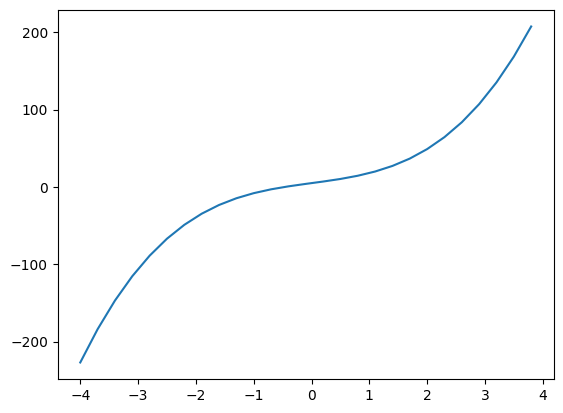

In [49]:
plt.plot(y, f(y))

def der(func, low, hi):
    ep = 0.01
    y = np.arange(low, hi, ep)
    r = (func(y + ep) - func(y))/ep
    return (y, r)

In [50]:
x = (f(y+0.00001)-f(y))/0.00001

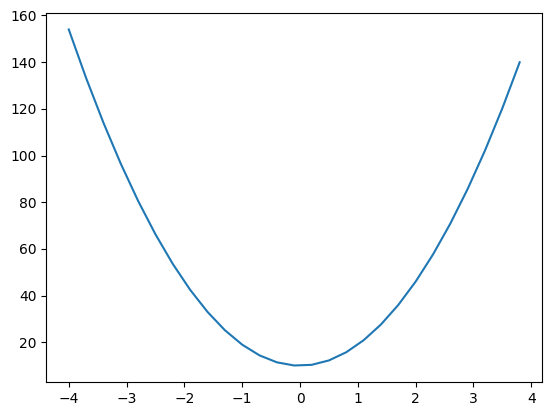

In [51]:
plt.plot(y, x)

In [45]:
k = -1
d = 0.00001
(f(k+d)-f(k))/d

4.000030000028687

In [78]:
!pip3 install graphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.3 MB/s eta 0:00:00

[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [85]:
# Graph visualization code from Andrej
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [287]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None
    def __repr__(self):
        return f"Value({self.label}={self.data})"
        
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        # out._backward should propagate its grad and update the grad for self and other.
        # essentially when invoked it should:
        # self.grad = out.grad (since its a + op)
        # other.grad = out.grad.
        # += Multivariate calculus: accumulation of gradients.
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        # += Multivariate calculus: accumulation of gradients.
        def _backward():
            self.grad += (other * self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), f'exp({self.data}')
        #print(f"exp called {self}")
        def _backward():
            #print(f"self={self}.grad = {self.grad}, out = {out}")
            self.grad += out.grad * out.data
            #print(f"self={self}.grad = {self.grad}, out.grad = {out.grad}, out.data={out.data}")
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self + other

    def __truediv__(self, other):
        return self * (other**-1)
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        # += Multivariate calculus: accumulation of gradients.
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1 )
        out = Value(t, _children = (self, ), _op='tanh')
        # += Multivariate calculus: accumulation of gradients.
        def _backward():
            # how do we know its the correct value t ? the forward pass will set this method using closure to
            # capture the right value of t.
            self.grad += (1 - t ** 2) * out.grad

        out._backward = _backward
        return out
    def backward(self):
        visited = set()
        topo_order = []
        def build_topo(visited, v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(visited, child)
                topo_order.append(v)
        self.grad = 1.0
        build_topo(visited, self)
        for n in reversed(topo_order):
            n._backward()
        

In [166]:

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L
#d = Value(0.1, label='a') + Value(0.5, label='b') * Value(2.0, label='c')
#d.label = 'd'



Value(L=-8.0)

In [198]:
def lgrad():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    print((L2 - L1) / h)

In [255]:
# the bias of a neuron is how trigger "happy" it is, higher bias can make it more trigger happy and less (vice versa). 
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'



p = (2*n).exp(); p.label = 'p'
r = (p - 1) / (p + 1); r.label = 'r'

exp called Value(=1.7627471740390863)


In [203]:
# this works only if you start with a node that has no parents, i.e. it is the last node.
def topsort_backward(node):
    visited = set()
    topo_order = []
    def build_topo(visited, v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(visited, child)
            topo_order.append(v)
    build_topo(visited, node)
    return topo_order

In [256]:

# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
r.backward()

self=Value(=1.7627471740390863).grad = 0.0, out = Value(p=5.828427124746192)
self=Value(=1.7627471740390863).grad = 0.25, out.grad = 0.04289321881345247, out.data=5.828427124746192


In [206]:
for n in reversed(ll):
    n._backward()

self=Value(=1.7627471740390863).grad = 0.0, out = Value(p=5.828427124746192)
self=Value(=1.7627471740390863).grad = 0.25, out.grad = 0.04289321881345247, out.data=5.828427124746192


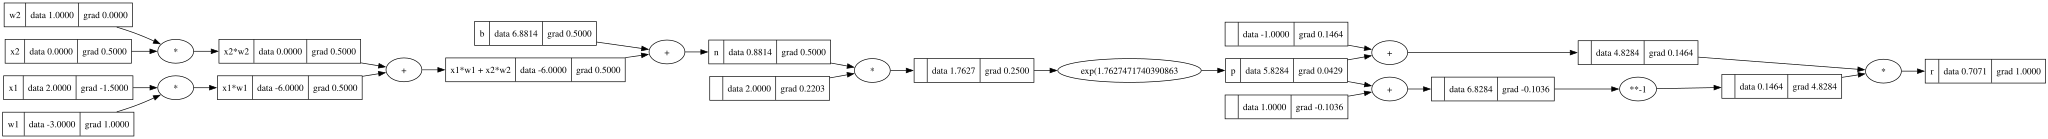

In [257]:

draw_dot(r)

In [134]:
# Multi-variate calculus gradients add. 
o.grad = 1.0
o = n.tanh(); o.label = 'o'
2 * o


Value(=1.4142135623730951)

In [168]:
o.grad=1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

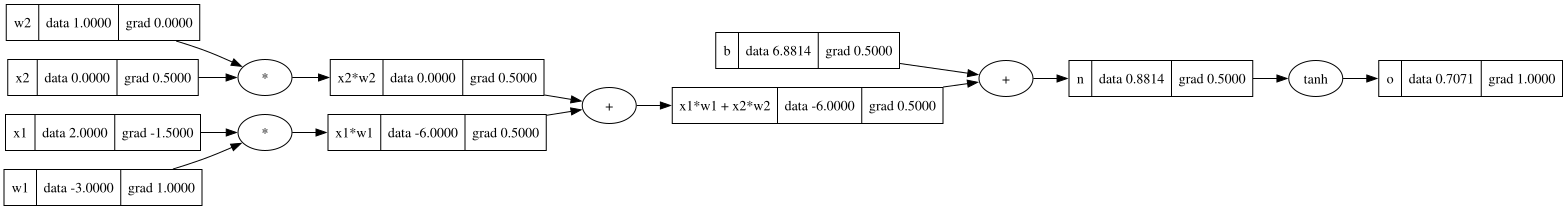

In [169]:
draw_dot(o)

In [317]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        #print(f"called with {x}")
        # wi*xi+b and then tanh() of that
        t = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return t.tanh()

    def __repr__(self):
        return f"Neuron({self.w}, {self.b})"

    def parameters(self):
        return [self.b] + self.w

In [318]:
class Layer:
    # nin = 
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    # list of nouts: defines the sizes of all layers in MLP
    # nin in the number of inputs for the whole MLP.
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.nin = nin
        print(f"MLP size list: {sizes}")
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(0, len(sizes)-1)]

    def __call__(self, x):
        assert len(x) == self.nin, f"Input size {x} should be {self.nin}"
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [300]:
# a = Neuron(3)
# y = a([9.0, .0, 0.3])
# l = Layer(2, 3)
# l([9.0, 4.5])

mlp = MLP(2, [3, 4, 5])
mlp([4.5, 8.9])

MLP size list: [2, 3, 4, 5]


[Value(=-0.03389342683791496),
 Value(=0.9937067365001433),
 Value(=-0.918402789076226),
 Value(=0.09931240935785544),
 Value(=-0.6229371908056691)]

In [281]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [325]:

def zero_grad(mlp):
    for p in mlp.parameters():
        p.grad = 0.0



In [339]:
n = MLP(3, [3, 5, 1])


MLP size list: [3, 3, 5, 1]


In [327]:
ypred = [n(x) for x in xs]
ypred

[Value(=-0.017505258018623612),
 Value(=-0.02784237575203389),
 Value(=-0.2631894999509168),
 Value(=-0.11459914197517954)]

In [328]:
# compute mean sq loss.
# print loss diagram. compute loss.backward()
# do a manual step of backprop by updating x.data using x.grad and 0.1
# check if loss goes down thereby confirming gradient descent works.

# automate GD with 20 steps and print loss going down.

# create nashgrad library and run the demo example, play with different architectures. 


In [329]:
loss = sum([(y2 - y1)**2 for y1, y2 in zip(ys, ypred)], 0.0)
loss

Value(=3.765628356753382)

In [330]:
loss.backward()

In [334]:
for p in n.parameters():
    print(p.grad)
print(len(n.parameters()))

-0.5889999556053676
-2.6075892066353066
1.5283883150517854
-1.3237054258796677
-0.3094893801991067
-0.4569555821227458
-0.5772425387144163
0.7552762201472483
-0.12539326830334635
-0.15314812355123092
-0.19840174206123726
0.38830515758694206
0.21895698760613225
0.4008071472097737
1.2518909105829161
0.017001852538742646
-0.09481863403956645
-0.09751904089648158
-0.1133597592641805
-0.07220507880551677
0.01957988779989671
0.0575996836179613
0.20298597653468367
0.001911925610242296
-0.18179963687479286
-0.2908066544943785
-0.7104374682986382
-0.08970603848481454
-0.794506946695267
-1.3394899374098053
-3.8057662808055066
-0.2977972515059545
-0.9199560345480053
-0.524194674147779
-0.9447998528488997
-0.8573061045804654
0.11025833403203955
-0.2920762173408198
38


In [335]:
# one loop of gd
learning_rate = 0.01
for p in n.parameters():
    p.data = p.data - learning_rate*p.grad


In [336]:
ypred = [n(x) for x in xs]
loss = sum([(y2 - y1)**2 for y1, y2 in zip(ys, ypred)], 0.0)
loss

Value(=3.4338820584689587)

In [414]:
num_steps = 200
learning_rate = 0.1
learning_rate_k = learning_rate
n = MLP(3, [3, 5, 1])
grad_db=[] # list of lists of gradient values at each step
data_db = []
for k in range(num_steps):
    # forward pass:
    ypred = [n(x) for x in xs]
    loss = sum([(y2 - y1)**2 for y1, y2 in zip(ys, ypred)], 0.0)
    # compute gradients - backward.
    zero_grad(n)
    loss.backward()
    # update parameters --
    for p in n.parameters():
        p.data = p.data - learning_rate_k*p.grad
    grad_db.append([p.grad for p in n.parameters()])
    data_db.append([p.data for p in n.parameters()])
    
    # zero grad
    # zero_grad(n)
    # learning rate decay
    learning_rate_k = learning_rate / (1 + 0.01 * k)
    print(f"Step {k}, loss {loss}, learning_rate = {learning_rate_k}")
    if (loss.data < 2.0e-30):
        break

MLP size list: [3, 3, 5, 1]
Step 0, loss Value(=7.454239554347852), learning_rate = 0.1
Step 1, loss Value(=4.0136467382865), learning_rate = 0.09900990099009901
Step 2, loss Value(=5.5474662249636335), learning_rate = 0.09803921568627451
Step 3, loss Value(=0.7442084032321756), learning_rate = 0.0970873786407767
Step 4, loss Value(=0.06772777289111519), learning_rate = 0.09615384615384616
Step 5, loss Value(=0.05133701832677347), learning_rate = 0.09523809523809523
Step 6, loss Value(=0.04202123407116967), learning_rate = 0.09433962264150944
Step 7, loss Value(=0.03575242497012788), learning_rate = 0.09345794392523364
Step 8, loss Value(=0.031178111216103158), learning_rate = 0.09259259259259259
Step 9, loss Value(=0.027671728937834754), learning_rate = 0.09174311926605505
Step 10, loss Value(=0.0248909205539336), learning_rate = 0.09090909090909091
Step 11, loss Value(=0.022628854213993393), learning_rate = 0.09009009009009009
Step 12, loss Value(=0.020751789614157162), learning_rate

In [407]:
[n(x) for x in xs]

[Value(=0.9789524995447103),
 Value(=-0.9751393010523828),
 Value(=-0.976770040453754),
 Value(=0.9819202203739155)]

In [408]:
for s in grad_db:
    out_str = ""
    for v in s:
        out_str += f"{v:.2f}, "
    print(out_str)

-1.08, -1.27, -1.49, 1.11, 0.07, 0.01, -0.05, -0.06, -3.43, -3.46, -3.60, 3.48, 0.51, 0.24, 0.34, -0.20, 0.27, 0.15, 0.18, -0.09, -1.59, -0.99, -1.01, 0.47, -1.79, -1.24, -1.11, 0.44, -1.77, -1.06, -1.12, 0.54, -2.28, -1.09, 0.05, 0.32, 0.75, 0.37, 
1.02, 0.69, 0.87, 0.98, 0.10, 0.05, 0.10, 0.10, 2.17, 3.81, -0.01, 1.63, -0.59, -0.33, -0.57, 0.43, -0.37, -0.23, -0.36, 0.28, 2.45, 1.45, 2.37, -1.82, 2.36, 1.84, 2.32, -1.86, 2.69, 1.56, 2.60, -1.99, 3.39, 0.77, -1.34, -0.49, -1.28, 0.13, 
-1.46, -2.91, -4.36, 1.46, 0.20, 0.39, 0.57, -0.20, -4.31, -8.55, -12.79, 4.31, 0.52, 0.19, 0.43, -0.01, -0.01, -0.00, -0.01, 0.00, -1.68, -0.59, -1.39, 0.04, -1.39, -0.51, -1.14, 0.01, -1.67, -0.60, -1.38, 0.03, -2.16, -0.63, 0.20, 0.17, 1.29, 0.40, 
1.42, 0.73, 1.41, 1.42, -0.06, -0.03, -0.06, -0.06, 2.42, 2.05, 1.74, 2.25, -0.42, -0.12, -0.38, -0.06, -0.04, -0.01, -0.03, -0.00, 1.18, 0.41, 1.08, 0.06, 1.58, 0.41, 1.44, 0.26, 1.44, 0.47, 1.33, 0.12, 2.18, 0.19, -0.33, 0.65, -0.95, 0.43, 
0.03, 0.02, 0

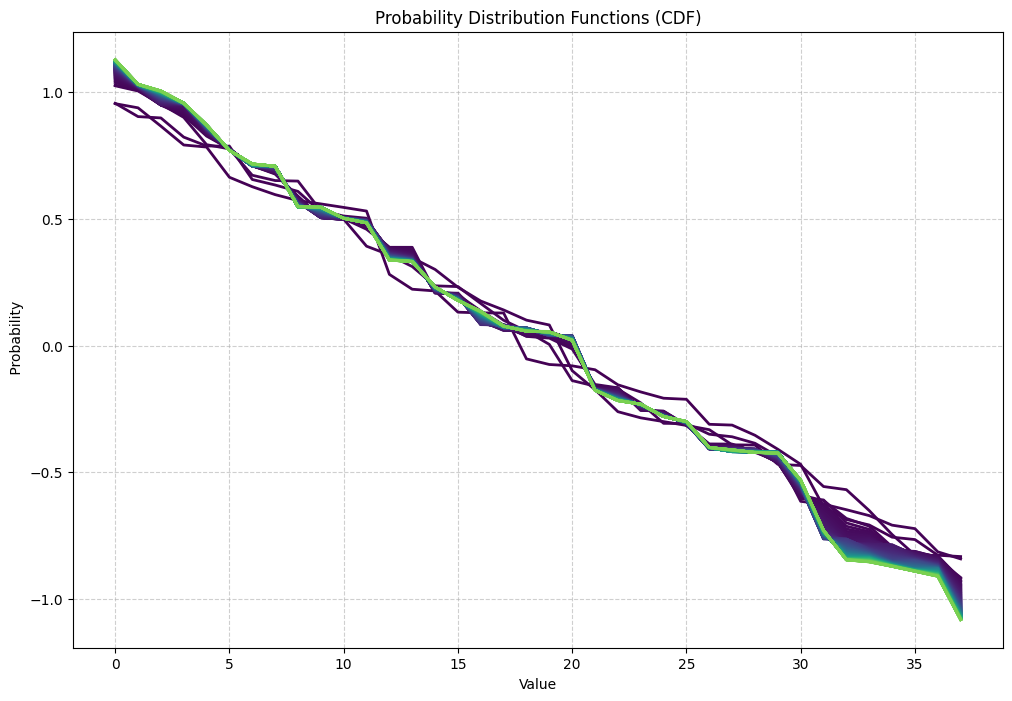

In [415]:
# Step 27, loss Value(=3.4307232056714987e-18)
# Step 28, loss Value(=1.7663101340064653e-21)
# Step 29, loss Value(=1.014216784493713e-24)
# Step 30, loss Value(=7.45917289693043e-28)
# Step 31, loss Value(=7.888609052210118e-31)

def plot_cdfs(values_db):
    # Generate a range of colors from a colormap (e.g., 'viridis' or 'plasma')
    # Use np.linspace to get equally spaced values between 0 and 1
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(values_db)))
    plt.figure(figsize=(12, 8))

    rms_values = []

    for i, data in enumerate(values_db):
        # 1. Sort the data in ascending order
        sorted_data = np.sort(data)[::-1]
        
        # 2. Calculate cumulative probability (y-axis from 0 to 1)
        # Formula: (index + 1) / total_count
        yvals = np.arange(1, len(sorted_data) + 1) / float(len(sorted_data))
        
        # 3. Plot the series using the generated color
        plt.plot(list(range(len(sorted_data))), sorted_data, color=colors[i], label=f'Series {i+1}', linewidth=2)

        rms = np.sqrt(np.mean(np.square(data)))
        rms_values.append(rms)

    plt.title('Probability Distribution Functions (CDF)')
    plt.xlabel('Value')
    plt.ylabel(' Probability')
    #plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    return rms_values

rms_values = plot_cdfs(data_db)

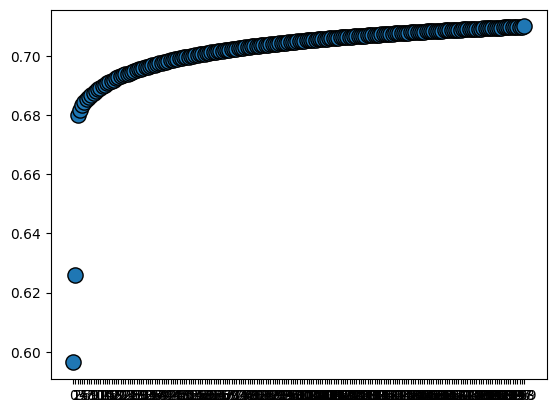

In [410]:
plt.scatter([f"{i}" for i in range(len(rms_values))], rms_values, s=120, zorder=3, edgecolors='black')

In [398]:
rms_values

[np.float64(0.6567176475511268),
 np.float64(0.6159240805954052),
 np.float64(0.7279870480865753),
 np.float64(0.8065941739370299),
 np.float64(0.9094175718722404),
 np.float64(1.098091271018681),
 np.float64(1.4394935955202737),
 np.float64(1.5661259597774777),
 np.float64(1.6423394788151724),
 np.float64(1.643935919841598),
 np.float64(1.6439660862572902),
 np.float64(1.6439671888049423),
 np.float64(1.6439672980326425),
 np.float64(1.6439673171635187),
 np.float64(1.6439673212035544),
 np.float64(1.643967322130742),
 np.float64(1.6439673223552391),
 np.float64(1.643967322411776),
 np.float64(1.6439673224264537),
 np.float64(1.6439673224303593),
 np.float64(1.6439673224314202),
 np.float64(1.6439673224317128),
 np.float64(1.6439673224317943),
 np.float64(1.6439673224318145),
 np.float64(1.643967322431788),
 np.float64(1.6439673223955094),
 np.float64(1.6696149272024403),
 np.float64(1.6696149272024405),
 np.float64(1.6696149272024403),
 np.float64(1.6696149272024403),
 np.float64(1.6

In [416]:
# Lesson: Since we have tanh() as the activation function, it absorbs higher values and squahes them well thus
# the network converges faster with "no_zero_grad". But with relu(), this won't work since the higher values are passed
# downstream, thus we need L2 reg and "zero_grad" also.

In [419]:
import torch
# Build a neural network bi-gram based. 
# Use torch.nn.functional one_hot, ensure dtype = torch.float32
# 

In [420]:
torch.randn((27, 1))

tensor([[-0.1319],
        [ 0.7572],
        [-0.2213],
        [ 0.4423],
        [-1.5852],
        [-1.5333],
        [-0.2263],
        [ 0.1753],
        [-0.2425],
        [-0.9378],
        [-0.4380],
        [-0.3001],
        [ 1.5882],
        [ 0.2756],
        [-1.0255],
        [-0.4771],
        [ 0.7968],
        [-1.3001],
        [-0.8917],
        [ 0.3534],
        [ 0.0221],
        [ 0.5642],
        [-0.5538],
        [-0.1632],
        [ 1.1631],
        [-1.1793],
        [ 1.1341]])